# Amazon Sales Analysis

Amazon sales product dataset contains product information, including pricing, discounts,
ratings, reviews, and user interactions. The following questions are designed to
analyze different aspects of the dataset using statistical methods.

* Download the dataset:

In [2]:
import requests

url = "https://drive.google.com/uc?export=download&id=1CkdzTki8Ai4YIesgpYwyCNs-r7Nt8Zvs"
response = requests.get(url, stream=True)

with open("dataset.zip", "wb") as file:
    for chunk in response.iter_content(chunk_size=1024):
        if chunk:
            file.write(chunk)

print("Download complete!")


Download complete!


In [3]:
import zipfile
import os

# Extract ZIP
with zipfile.ZipFile("dataset.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

# Find CSV file
csv_files = [f for f in os.listdir("dataset") if f.endswith(".csv")]
if csv_files:
    import pandas as pd
    df = pd.read_csv(f"dataset/{csv_files[0]}")
else:
    print("No CSV found.")

In [4]:
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

## 1. Does the discounted price significantly impact product ratings?

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [8]:
from scipy.stats import spearmanr

# data
X = df.discounted_price
Y = df.rating

# Calculate Spearman correlation
corr, p_value = spearmanr(X, Y)

print(f"Spearman Correlation: {corr:.3f}")
print(f"P-value: {p_value:.3f}")  # P-value for significance test

Spearman Correlation: 0.076
P-value: 0.004


In [9]:
rows_with_pipe = df[df["rating"].str.contains("|", regex=False)]
rows_with_pipe

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
1279,B08L12N5H1,Eureka Forbes car Vac 100 Watts Powerful Sucti...,"Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cle...","₹2,099","₹2,499",16%,|,992,No Installation is provided for this product|1...,"AGTDSNT2FKVYEPDPXAA673AIS44A,AER2XFSWNN4LAUCJ5...","Divya,Dr Nefario,Deekshith,Preeti,Prasanth R,P...","R2KKTKM4M9RDVJ,R1O692MZOBTE79,R2WRSEWL56SOS4,R...","Decent product,doesn't pick up sand,Ok ok,Must...","Does the job well,doesn't work on sand. though...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Eureka-Forbes-Vacuum-Cle...


In [10]:
df = df.drop(1279)

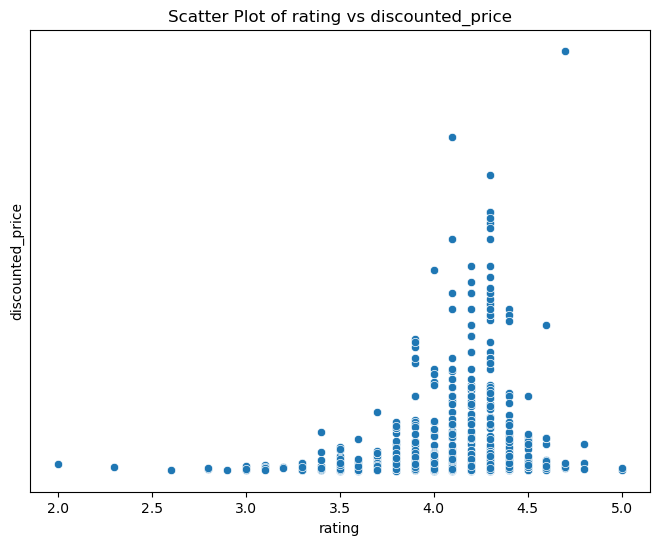

In [11]:
plt.figure(figsize=(8, 6)) 

data = pd.DataFrame({"rating": pd.to_numeric(df["rating"], errors="coerce"), 
                     "discounted_price": df["discounted_price"].str.replace("₹", "", regex=False)
                     .str.replace(",", "", regex=False).astype(float)})

sns.scatterplot(x="rating", y="discounted_price", data=data)

plt.yticks(range(0))
plt.title("Scatter Plot of rating vs discounted_price")
plt.xlabel("rating")
plt.ylabel("discounted_price")
plt.show()

Practical Meaning: The correlation is almost negligible (ρ = 0.076), meaning that X and Y have little relationship.
Statistical Meaning: The p-value (0.004) suggests that this weak correlation is unlikely due to random chance.

Statistical Significance Does NOT Mean Strong Relationship

A small p-value only means there is evidence that ρ is different from zero.
But it doesn’t mean the correlation is strong or meaningful.
Spearman Measures Monotonicity, Not Linearity

Even if Spearman's ρ is low, there could be non-monotonic (but still structured) relationships in the data.

## 2. Are product categories and high/low ratings independent?

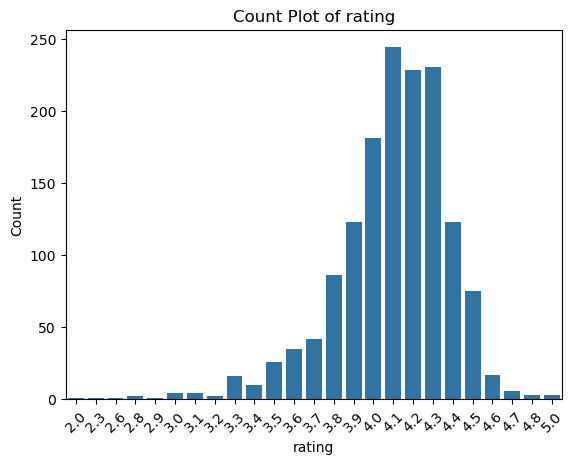

In [14]:
# Create count plot for a specific column
sns.countplot(x=data["rating"])

plt.title("Count Plot of rating")
plt.xlabel("rating")
plt.ylabel("Count")
plt.xticks(rotation=45)  # Rotate labels if needed
plt.show()

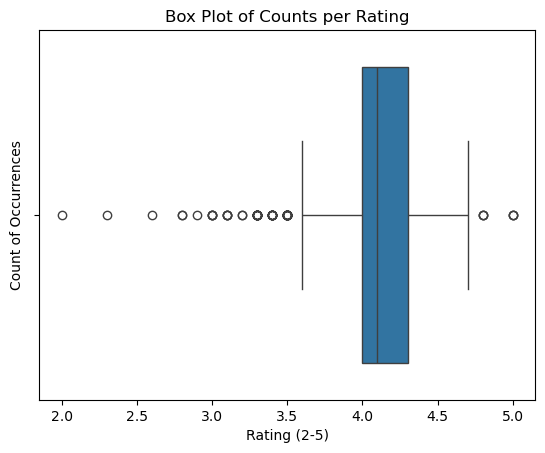

In [15]:
# Create boxplot 
sns.boxplot(x=data["rating"])

plt.title("Box Plot of Counts per Rating")
plt.xlabel("Rating (2-5)")
plt.ylabel("Count of Occurrences")
plt.show()

In [16]:
from scipy.stats import chi2_contingency

data["rating_level"] = data["rating"].apply(lambda x: "High" if x >= 4.1 else "Low")
data["category"] = df["category"]

contingency_table = pd.crosstab(data["category"], data["rating_level"], )
contingency_table

rating_level,High,Low
category,,
Car&Motorbike|CarAccessories|InteriorAccessories|AirPurifiers&Ionizers,0,1
Computers&Accessories|Accessories&Peripherals|Adapters|USBtoUSBAdapters,1,1
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCHeadsets,0,1
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCMicrophones,0,2
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCSpeakers,1,1
...,...,...
"OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|GelInkRollerballPens",2,0
"OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|LiquidInkRollerballPens",2,0
"OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|RetractableBallpointPens",2,0


the number of rows(categories) are too big, it causes big DoF(Degree og Freedom)
So we reduce the categories to the majors:

In [18]:
data["category"] = data["category"].str.split("|").str[0]

contingency_table = pd.crosstab(data["category"], data["rating_level"], )
contingency_table

rating_level,High,Low
category,,
Car&Motorbike,0,1
Computers&Accessories,316,137
Electronics,329,197
Health&PersonalCare,0,1
Home&Kitchen,252,195
HomeImprovement,1,1
MusicalInstruments,0,2
OfficeProducts,30,1
Toys&Games,1,0


some of these categories have a really small expected frequency, so we combine them to the "Other" category: 

In [20]:
data["category"] = data["category"].replace({
    "Car&Motorbike": "Other",
    "Health&PersonalCare": "Other",
    "HomeImprovement": "Other",
    "MusicalInstruments": "Other",
    "Toys&Games": "Other"
    
    # Add more categories to combine as needed
})

contingency_table = pd.crosstab(data["category"], data["rating_level"], )
contingency_table

rating_level,High,Low
category,,
Computers&Accessories,316,137
Electronics,329,197
Home&Kitchen,252,195
OfficeProducts,30,1
Other,2,5


In [21]:
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2:.3f}")
print(f"P-value: {p:.5f}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies:\n", expected)

Chi-Square Statistic: 36.120
P-value: 0.00000
Degrees of Freedom: 4
Expected Frequencies:
 [[287.45696721 165.54303279]
 [333.78005464 192.21994536]
 [283.64959016 163.35040984]
 [ 19.67144809  11.32855191]
 [  4.44193989   2.55806011]]


the final "Expected Frequencies" for "Other" is smaller than 5, so the test may not be valid. So we remove it for the test to be reliable:

In [23]:
data = data[data["category"] != "Other"]
contingency_table = pd.crosstab(data["category"], data["rating_level"], )
contingency_table

rating_level,High,Low
category,,
Computers&Accessories,316,137
Electronics,329,197
Home&Kitchen,252,195
OfficeProducts,30,1


In [24]:
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2:.3f}")
print(f"P-value: {p:.5f}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies:\n", expected)

Chi-Square Statistic: 32.492
P-value: 0.00000
Degrees of Freedom: 3
Expected Frequencies:
 [[288.21619767 164.78380233]
 [334.66163349 191.33836651]
 [284.39876458 162.60123542]
 [ 19.72340426  11.27659574]]


## 3. Is there a significant difference in ratings between high-discount and low-discount products?

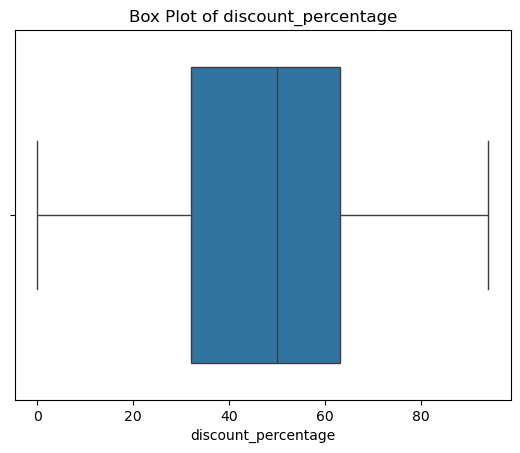

In [26]:
data["discount_percentage"] = df["discount_percentage"].str.split("%").str[0].astype(float)
# Create boxplot 
sns.boxplot(x=data["discount_percentage"])

plt.title("Box Plot of discount_percentage")
plt.xlabel("discount_percentage")
plt.show()

In [27]:
data["discount_level"] = data["discount_percentage"].apply(lambda x: "High" if x >= 50 else "Low")

grouped_stat = data.groupby("discount_level").agg(
    mean_value=("rating", "mean"),  # Mean of the group
    variance_value=("rating", "var"),  # Variance of the group
    group_size=("rating", "size")  # Number of elements in each group
)

grouped_stat

,mean_value,variance_value,group_size
discount_level,,,
High,4.064926,0.096302,747
Low,4.130282,0.071451,710


In [28]:
a = grouped_stat.mean_value.iloc[1] - grouped_stat.mean_value.iloc[0]
b = (grouped_stat.variance_value.iloc[0]**2)/grouped_stat.group_size.iloc[0] 
c = (grouped_stat.variance_value.iloc[1]**2)/grouped_stat.group_size.iloc[1]

t_stat = a/((b+c)**(0.5))
print(f"t-Statistic: {t_stat:.3f}")


t-Statistic: 14.760


In [29]:
from scipy.stats import t

dof = grouped_stat.group_size.iloc[0] + grouped_stat.group_size.iloc[1] - 2 # Degrees of freedom

# Two-tailed p-value
p_value = 2 * t.sf(abs(t_stat), dof)  # sf = survival function (1 - CDF)

print(f"P-value: {p_value:.5f}")

P-value: 0.00000


With such large dof, the t-test behaves almost like a z-test (normal distribution).
The result is saying: “The difference is so significant that it is almost impossible to occur by chance.”

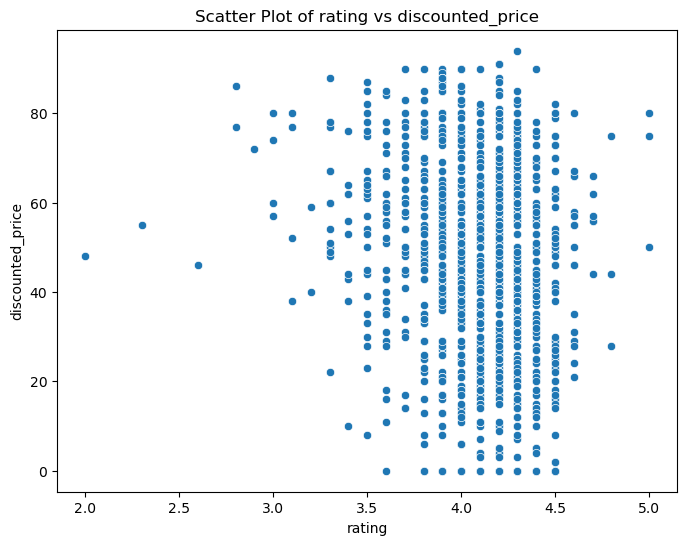

In [31]:
plt.figure(figsize=(8, 6)) 

sns.scatterplot(x="rating", y="discount_percentage", data=data)

plt.title("Scatter Plot of rating vs discounted_price")
plt.xlabel("rating")
plt.ylabel("discounted_price")
plt.show()

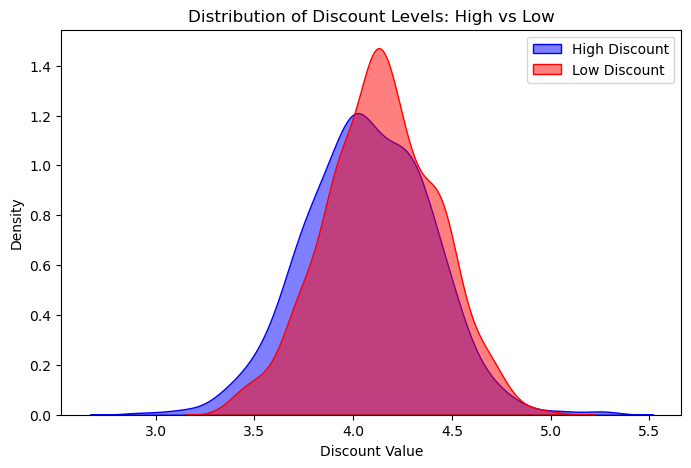

In [32]:
# Given means, variances, and sample sizes
mean1, mean2 = grouped_stat.mean_value.iloc[0], grouped_stat.mean_value.iloc[1]
var1, var2 = grouped_stat.variance_value.iloc[0], grouped_stat.variance_value.iloc[1]
n1, n2 = grouped_stat.group_size.iloc[0], grouped_stat.group_size.iloc[1]

# Simulate data for both groups using normal distribution
group1 = np.random.normal(loc=mean1, scale=np.sqrt(var1), size=n1)
group2 = np.random.normal(loc=mean2, scale=np.sqrt(var2), size=n2)

# Plot the distributions
plt.figure(figsize=(8, 5))
sns.kdeplot(group1, color='blue', label='High Discount', fill=True, alpha=0.5)
sns.kdeplot(group2, color='red', label='Low Discount', fill=True, alpha=0.5)

# Add labels and title
plt.title('Distribution of Discount Levels: High vs Low')
plt.xlabel('Discount Value')
plt.ylabel('Density')
plt.legend()
plt.show()


Since the data from both groups are similar and normal, the assumptions for the t-test (such as normality) are met.

 Although the p-value is very small (close to 0), the difference in means might not be practically significant. The t-test just shows that the observed difference is statistically significant.

## 4. Do more expensive products receive higher ratings on average?

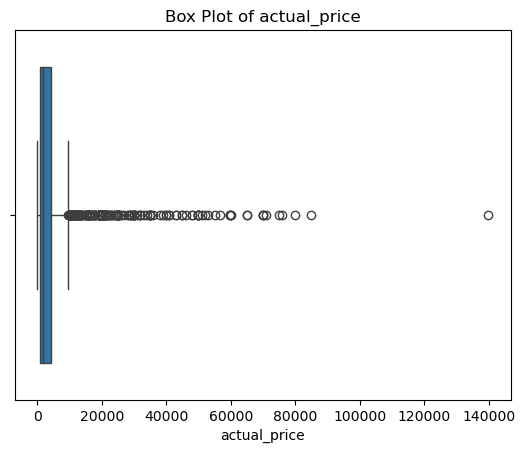

In [35]:
data["actual_price"] = df["actual_price"].str.replace("₹", "", regex=False).str.replace(",", "", regex=False).astype(float)
# Create boxplot 
sns.boxplot(x=data["actual_price"])

plt.title("Box Plot of actual_price")
plt.xlabel("actual_price")
plt.show()

Price distribution is skewed based on the box plot, using quantiles is a good approach to divide products into price groups:

In [37]:
data["price_level"] = pd.qcut(data["actual_price"], q=3, labels=["Low", "Medium", "High"])

* Group the data by price_level and calculate group means and the overall mean:

In [39]:
grouped = data.groupby("price_level", observed=True)["rating"]
group_sizes = grouped.count()

group_means = grouped.mean()
overall_mean = data["rating"].mean()

* Calculate the variances:

In [41]:
# Calculate the variance within each group
group_variances = grouped.var(ddof=1)

# Calculate the between-group variance
between_group_variance = sum(group_sizes * (group_means - overall_mean) ** 2) / (len(group_sizes) - 1)

# Calculate the within-group variance
within_group_variance = sum((group_sizes - 1) * group_variances) / (len(data) - len(group_sizes))

* Compute the F-statistic:

In [43]:
f_statistic = between_group_variance / within_group_variance

print(f"Group Means:\n{group_means}\n")
print(f"Overall Mean: {overall_mean:.3f}\n")
print(f"Group Sizes:\n{group_sizes}\n")
print(f"Group Variances:\n{group_variances}\n")
print(f"Between-group variance: {between_group_variance:.3f}")
print(f"Within-group variance: {within_group_variance:.3f}")
print(f"F-statistic: {f_statistic:.3f}")

Group Means:
price_level
Low       4.082353
Medium    4.102581
High      4.107312
Name: rating, dtype: float64

Overall Mean: 4.097

Group Sizes:
price_level
Low       527
Medium    465
High      465
Name: rating, dtype: int64

Group Variances:
price_level
Low       0.088566
Medium    0.107278
High      0.059300
Name: rating, dtype: float64

Between-group variance: 0.088
Within-group variance: 0.085
F-statistic: 1.038


* Calculate degrees of freedom:

In [45]:
# Number of groups
k = data["price_level"].nunique()  # Number of distinct price levels (it's 3, high, low and medium)

# Total number of observations
N = len(data)

# Between-group degrees of freedom
df_between = k - 1

# Within-group degrees of freedom
df_within = N - k

* Finding critical point for our test:

In [47]:
import scipy.stats as stats

alpha = 0.05
critical_value = stats.f.ppf(1 - alpha, df_between, df_within)
critical_value

3.0019129829411924

The f-statistic is smaller than the critical F-value. so we fail to reject the null hypothesis indicating that the groups are not significantly different.

In [49]:
p_value = 1 - stats.f.cdf(f_statistic, df_between, df_within)
p_value

0.35433684306160806

The P_value also confirms the result (it's too bigger than for example 0.05)

## 5. Does the distribution of rating counts follow a normal distribution?

In [52]:
data["rating_count"] = df["rating_count"].str.replace(",", "", regex=False).astype(float)

In [53]:
data[data["rating_count"].isna()]

,rating,discounted_price,rating_level,category,discount_percentage,discount_level,actual_price,price_level,rating_count
282,3.0,199.0,Low,Computers&Accessories,80.0,High,999.0,Low,NaN
324,5.0,249.0,High,Computers&Accessories,75.0,High,999.0,Low,NaN


In [54]:
# Sort the "rating_count" data
rating_count_sorted = np.sort(data["rating_count"].dropna())
n = len(rating_count_sorted)

* Compute the Empirical CDF (ECDF) and Normal CDF:

In [56]:
# Compute the Empirical CDF (ECDF)
F_n = np.arange(1, n+1) / n  # ECDF values

# Compute the Normal CDF
mu, sigma = np.mean(rating_count_sorted), np.std(rating_count_sorted, ddof=1)
F_x = stats.norm.cdf(rating_count_sorted, loc=mu, scale=sigma)

* Kolmogorov-Smirnov Test:

In [58]:
D_n = np.max(np.abs(F_n - F_x))

print("ECDF Values:", F_n)
print("Normal CDF Values:", F_x)
print(f"Kolmogorov-Smirnov Statistic (D_n): {D_n:.5f}")

ECDF Values: [6.87285223e-04 1.37457045e-03 2.06185567e-03 ... 9.98625430e-01
 9.99312715e-01 1.00000000e+00]
Normal CDF Values: [0.33452734 0.33452734 0.33454434 ... 1.         1.         1.        ]
Kolmogorov-Smirnov Statistic (D_n): 0.33384


In [59]:
from scipy.stats import kstest, norm

statistic, p_value = kstest(data["rating_count"].dropna(), "norm", args=(data["rating_count"].mean(), data["rating_count"].std()))

print(f"Kolmogorov-Smirnov Test Statistic: {statistic:.4f}")
print(f"P-value: {p_value:.4f}")

Kolmogorov-Smirnov Test Statistic: 0.3345
P-value: 0.0000


<Axes: xlabel='rating_count', ylabel='Count'>

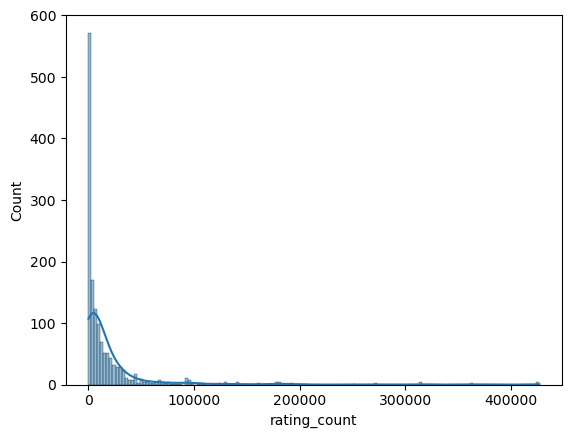

In [60]:
sns.histplot(data["rating_count"], kde=True)

A Kolmogorov-Smirnov (KS) test statistic of 0.3345 means that the maximum difference between the empirical cumulative distribution function (ECDF) of your rating_count data and the cumulative distribution function (CDF) of a normal distribution is 33.45%. So, the data is not well-matched to a normal distribution. And since P_value is 0, it rejects the null hypothesis (data is not normal).